# **Processamento Digital de Sinais — 1ª Avaliação**

## Questão 1

In [4]:
import numpy as np
import matplotlib.pyplot as plt

### a) Sinal original — verificação do período $N = 5$

$\dfrac{12\pi}{5}N = 2\pi r \Rightarrow N = \dfrac{5r}{6}$, menor $r$ inteiro é $r=6 \Rightarrow N = 5$.

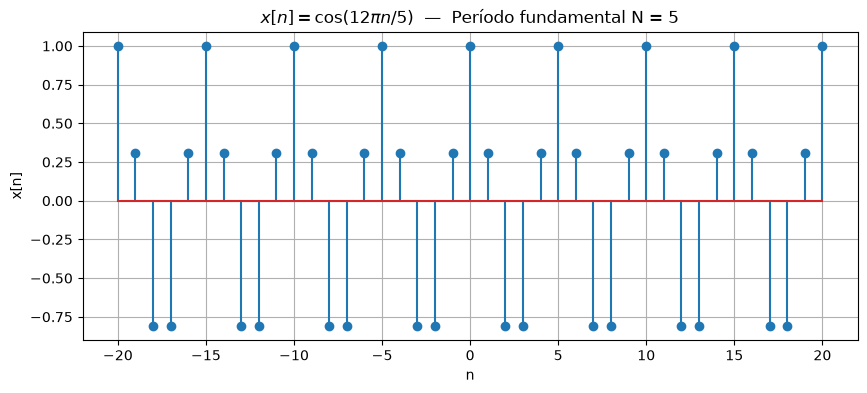

In [5]:
n = np.arange(-20, 21)
x = np.cos((12*np.pi/5)*n)

plt.figure(figsize=(10, 4))
plt.stem(n, x)
plt.xlabel('n')
plt.ylabel('x[n]')
plt.title(r'$x[n] = \cos(12\pi n / 5)$  —  Período fundamental N = 5')
plt.grid(True)
plt.savefig('grafico_1a.png', dpi=150, bbox_inches='tight')
plt.show()

## b) Efeito da multiplicação da frequência no período

**Frequência × 2:** $\omega_0' = \dfrac{24\pi}{5}$ → $N = \dfrac{5r}{12}$, menor $r=12 \Rightarrow N = 5$ (o período **não muda**).

**Frequência × 5:** $\omega_0'' = 12\pi$ → $N = \dfrac{r}{6}$, menor $r=6 \Rightarrow N = 1$ (sinal vira **constante**, pois $12\pi n$ é sempre múltiplo de $2\pi$).

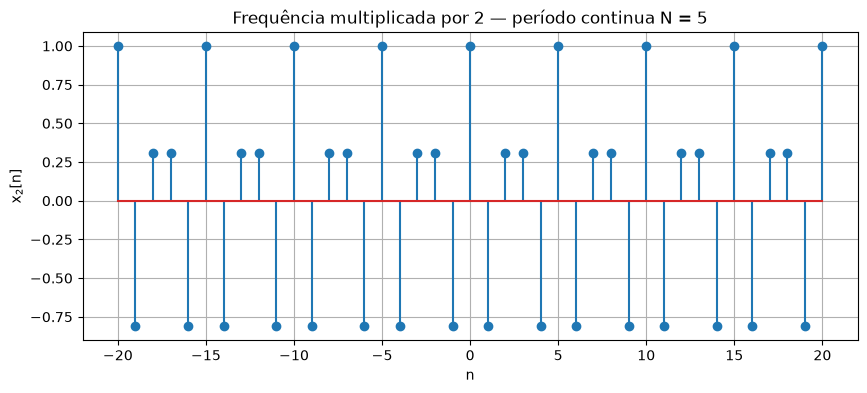

In [6]:
n = np.arange(-20, 21)

x2 = np.cos(2*(12*np.pi/5)*n)   # frequência x2

plt.figure(figsize=(10, 4))
plt.stem(n, x2)
plt.xlabel('n')
plt.ylabel('x$_2$[n]')
plt.title('Frequência multiplicada por 2 — período continua N = 5')
plt.grid(True)
plt.savefig('grafico_1b_x2.png', dpi=150, bbox_inches='tight')
plt.show()

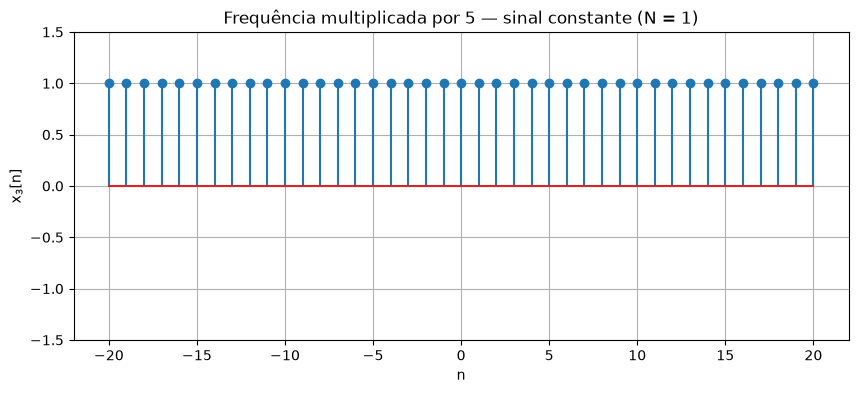

In [7]:
x3 = np.cos(5*(12*np.pi/5)*n)   # frequência x5

plt.figure(figsize=(10, 4))
plt.stem(n, x3)
plt.xlabel('n')
plt.ylabel('x$_3$[n]')
plt.title('Frequência multiplicada por 5 — sinal constante (N = 1)')
plt.grid(True)
plt.ylim(-1.5, 1.5)
plt.savefig('grafico_1b_x5.png', dpi=150, bbox_inches='tight')
plt.show()

## Baixando os gráficos gerados

Execute a célula abaixo no Colab para baixar as 3 imagens direto para o seu computador (para colar no LaTeX).

In [8]:
from google.colab import files

files.download('grafico_1a.png')
files.download('grafico_1b_x2.png')
files.download('grafico_1b_x5.png')

ModuleNotFoundError: No module named 'google'

## Questão 3 — Convolução

Para um sistema linear e invariante no tempo, a saída é a convolução entre a entrada $x[n]$ e a resposta ao impulso $h[n]$:

$$y[n]=(x*h)[n]=\sum_{k=-\infty}^{\infty}x[k]h[n-k].$$

Como os sinais do enunciado são causais, $x[n]=h[n]=0$ para $n<0$, e o somatório se reduz a

$$y[n]=\sum_{k=0}^{n}x[k]h[n-k].$$

Se `x` possui $N_x$ amostras e `h` possui $N_h$ amostras, a saída completa possui $N_x+N_h-1$ amostras. A implementação abaixo calcula diretamente cada produto $x[k]h[m]$ e o acumula em $y[k+m]$, sem usar funções prontas de convolução.

In [9]:
def Convolucao(x, h):
    """Calcula a convolução completa de dois sinais causais sem np.convolve."""
    x = np.asarray(x)
    h = np.asarray(h)

    if x.ndim != 1 or h.ndim != 1:
        raise ValueError("x e h devem ser vetores unidimensionais.")
    if x.size == 0 or h.size == 0:
        raise ValueError("x e h não podem ser vetores vazios.")

    tipo = np.result_type(x.dtype, h.dtype)
    y = np.zeros(x.size + h.size - 1, dtype=tipo)

    for k in range(x.size):
        for m in range(h.size):
            y[k + m] += x[k] * h[m]

    return y

### Exemplo

Para $x[n]=\{1, 2, 3\}$ e $h[n]=\{1, 0{,}5\}$, com ambos começando em $n=0$, espera-se $y[n]=\{1; 2{,}5; 4; 1{,}5\}$.

In [11]:
x_exemplo = np.array([1, 2, 3])
h_exemplo = np.array([1, 0.5])
y_exemplo = Convolucao(x_exemplo, h_exemplo)

print("x[n] =", x_exemplo)
print("h[n] =", h_exemplo)
print("y[n] =", y_exemplo)

x[n] = [1 2 3]
h[n] = [1.  0.5]
y[n] = [1.  2.5 4.  1.5]


## Questão 4 — Investimento

A equação dada pode ser escrita como

$$y[n]=(1+r)y[n-1]+x[n].$$

Definindo $a=1+r$, a resposta ao impulso do sistema é $h[n]=a^n u[n]$. Como o aporte é constante e começa no primeiro mês, $x[n]=x\,u[n-1]$. A resposta total é a soma da resposta à condição inicial com a convolução dos aportes e da resposta ao impulso:

$$y[n]=a^ny_0+\sum_{k=1}^{n}x\,h[n-k]
=a^ny_0+x\sum_{m=0}^{n-1}a^m.$$

Logo, para $r\neq0$,

$$\boxed{y[n]=y_0(1+r)^n+x\frac{(1+r)^n-1}{r}}.$$

Para $r=0$, a expressão se reduz a $\boxed{y[n]=y_0+nx}$. Assim, a implementação abaixo é uma solução fechada, e não uma iteração recursiva. A taxa deve ser informada na forma decimal (por exemplo, `0.01` para 1% ao mês).

In [12]:
def Investimento(y0, r, x, n):
    """Calcula o saldo após n meses por meio da solução fechada.

    O aporte x é realizado ao final de cada mês e r é uma taxa decimal.
    """
    if not isinstance(n, (int, np.integer)) or isinstance(n, (bool, np.bool_)):
        raise TypeError("n deve ser um número inteiro de meses.")
    if n < 0:
        raise ValueError("n não pode ser negativo.")
    if r <= -1:
        raise ValueError("r deve ser maior que -1.")

    if np.isclose(r, 0.0):
        return y0 + n*x

    fator = (1 + r)**n
    soma_aportes = np.expm1(n*np.log1p(r))/r
    return y0*fator + x*soma_aportes

### Exemplo

Investimento inicial de R$ 1.000,00, rentabilidade de 1% ao mês, aporte mensal de R$ 200,00 e prazo de 12 meses.

In [13]:
valor = Investimento(1000, 0.01, 200, 12)
print(f"Valor final do investimento: R$ {valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

Valor final do investimento: R$ 3.663,33
